
##  PPO on Airstriker-Genesis 

---
##  Setup

In [101]:
import collections
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

import stable_retro
import cv2  # for frame preprocessing

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


---
##  Environment + Preprocessing



In [102]:
#  Discrete action set 
# Airstriker buttons: [B, A, MODE, START, UP, DOWN, LEFT, RIGHT, C, Y, X, Z]
ACTIONS = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 0: NOOP
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # 1: LEFT
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],  # 2: RIGHT
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # 3: UP
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # 4: DOWN
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 5: FIRE (B button)
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # 6: FIRE + LEFT
    [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],  # 7: FIRE + RIGHT
    [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # 8: FIRE + UP
    [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # 9: FIRE + DOWN
]
N_ACTIONS = len(ACTIONS)


class FramePreprocessor:
    """Converts raw game frames to 84x84 grayscale, normalised to [0, 1]."""

    def __init__(self, frame_size=84):
        self.frame_size = frame_size

    def __call__(self, frame):
        # frame: (H, W, 3) uint8  →  (84, 84) float32
        gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        resized = cv2.resize(gray, (self.frame_size, self.frame_size),
                             interpolation=cv2.INTER_AREA)
        return resized.astype(np.float32) / 255.0


class FrameStack:
   

    def __init__(self, k=4, frame_size=84):
        self.k = k
        self.frames = collections.deque(maxlen=k)
        self.preprocessor = FramePreprocessor(frame_size)

    def reset(self, frame):
        processed = self.preprocessor(frame)
      
        for _ in range(self.k):
            self.frames.append(processed)
        return self._get_obs()

    def step(self, frame):
        self.frames.append(self.preprocessor(frame))
        return self._get_obs()

    def _get_obs(self):
        # Stack along channel dim: (4, 84, 84)
        return np.stack(self.frames, axis=0)



def make_env():
    env = stable_retro.make(game="Airstriker-Genesis-v0")
    return env


def env_step(env, frame_stack, action_idx,prev_score=0, prev_lives=3):
    
    action = ACTIONS[action_idx]
    frame, reward, terminated, truncated, info = env.step(action)
    obs = frame_stack.step(frame)
    done = terminated or truncated
    score_delta = info.get('score', 0) - prev_score          
    kill_bonus = score_delta * 0.1 if score_delta > 0 else 0.0  
    lives_delta = info.get('lives', 3) - prev_lives           
    death_penalty = -0.1 if lives_delta < 0 else 0.0 
    survival_bonus = 0.001 if not done else 0.0
    total_reward = reward + kill_bonus + survival_bonus + death_penalty  
    return obs, np.clip(total_reward, -5.0, 5.0), done, info


def env_reset(env, frame_stack):
    
    frame, info = env.reset()
    obs = frame_stack.reset(frame)
    return obs, info


print(f"Action space size: {N_ACTIONS} discrete actions")

Action space size: 10 discrete actions


---
##  CNN Actor-Critic Network



In [103]:
def init_weights(module):
    
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
        nn.init.constant_(module.bias, 0.0)


class CNNActorCritic(nn.Module):
    

    def __init__(self, n_actions):
        super().__init__()

       
        self.cnn = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),  # (4,84,84) → (32,20,20)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2), # (32,20,20) → (64,9,9)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), # (64,9,9)  → (64,7,7)
            nn.ReLU(),
            nn.Flatten(),                               # → 3136
        )

        cnn_output_size = 64 * 7 * 7  # = 3136

        # Shared fully-connected layer after CNN
        self.shared_fc = nn.Sequential(
            nn.Linear(cnn_output_size, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Linear(512, 256),  
            nn.ReLU(),
            nn.LayerNorm(256),
        )

        #  Actor Head 
        
        self.actor_head = nn.Linear(256, n_actions)

        # Critic Head
        
        self.critic_head = nn.Linear(256, 1)

        
        self.apply(init_weights)
        
        nn.init.orthogonal_(self.actor_head.weight, gain=0.01)
        
        nn.init.orthogonal_(self.critic_head.weight, gain=1.0)

    def forward(self, x):
        
        features = self.shared_fc(self.cnn(x))
        action_logits = self.actor_head(features)
        values = self.critic_head(features).squeeze(-1)
        return action_logits, values

    def get_action(self, obs):
        
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)  # (1, 4, 84, 84)
        with torch.no_grad():
            logits, value = self.forward(obs_t)
        dist = Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob.squeeze(), value.squeeze()

    def evaluate_actions(self, obs_batch, actions_batch):
       
        logits, values = self.forward(obs_batch)
        dist = Categorical(logits=logits)
        log_probs = dist.log_prob(actions_batch)
        entropy = dist.entropy()  
        return log_probs, values, entropy



test_model = CNNActorCritic(N_ACTIONS)
test_obs = torch.zeros(1, 4, 84, 84)
logits, values = test_model(test_obs)
print(f"Actor output shape:  {logits.shape}  (expect: [1, {N_ACTIONS}])")
print(f"Critic output shape: {values.shape}  (expect: [1])")

Actor output shape:  torch.Size([1, 10])  (expect: [1, 10])
Critic output shape: torch.Size([1])  (expect: [1])


---
##  Rollout Buffer



In [104]:
class RolloutBuffer:
    """
    Stores a fixed-length rollout of experience for a single PPO update.
    """

    def __init__(self, rollout_steps, obs_shape, gamma=0.99, gae_lambda=0.95):
        self.rollout_steps = rollout_steps
        self.gamma = gamma          # Discount factor: how much we value future rewards
        self.gae_lambda = gae_lambda  # GAE smoothing: 0=high bias, 1=high variance

        # Pre-allocate numpy arrays for efficiency
        self.obs      = np.zeros((rollout_steps, *obs_shape), dtype=np.float32)
        self.actions  = np.zeros(rollout_steps, dtype=np.int64)
        self.log_probs= np.zeros(rollout_steps, dtype=np.float32)
        self.rewards  = np.zeros(rollout_steps, dtype=np.float32)
        self.dones    = np.zeros(rollout_steps, dtype=np.float32)
        self.values   = np.zeros(rollout_steps, dtype=np.float32)

        self.returns    = np.zeros(rollout_steps, dtype=np.float32)
        self.advantages = np.zeros(rollout_steps, dtype=np.float32)

        self.ptr = 0  # Current write position

    def store(self, obs, action, log_prob, reward, done, value):
        self.obs[self.ptr]       = obs
        self.actions[self.ptr]   = action
        self.log_probs[self.ptr] = log_prob
        self.rewards[self.ptr]   = reward
        self.dones[self.ptr]     = float(done)
        self.values[self.ptr]    = value
        self.ptr += 1

    def compute_returns_and_advantages(self, last_value):
       
        gae = 0.0
        
        for t in reversed(range(self.rollout_steps)):
            next_value = last_value if t == self.rollout_steps - 1 else self.values[t + 1]
            next_non_terminal = 1.0 - self.dones[t]

            
            delta = (self.rewards[t]
                     + self.gamma * next_value * next_non_terminal
                     - self.values[t])

            # GAE accumulates discounted TD errors backwards
            gae = delta + self.gamma * self.gae_lambda * next_non_terminal * gae
            self.advantages[t] = gae

        
        self.returns = (
        (self.returns - self.returns.mean())
        / (self.returns.std() + 1e-8)
    )

       
        self.advantages = (
            (self.advantages - self.advantages.mean())
            / (self.advantages.std() + 1e-8)
        )

    def get_tensors(self):
        
        return (
            torch.FloatTensor(self.obs).to(device),
            torch.LongTensor(self.actions).to(device),
            torch.FloatTensor(self.log_probs).to(device),
            torch.FloatTensor(self.returns).to(device),
            torch.FloatTensor(self.advantages).to(device),
        )

    def reset(self):
        self.ptr = 0


print("Rb done")

Rb done


---
##  PPO Update



In [105]:
class PPO:
    

    def __init__(
        self,
        n_actions,
        lr=2.5e-4,          # Learning rate
        clip_eps=0.2,       
        value_coef=0.5,     # c1: weight of value loss
        entropy_coef=0.02,  # c2: weight of entropy bonus (encourages exploration)
        max_grad_norm=0.5,  # Gradient clipping norm
        n_epochs=10,         # Number of passes over the rollout data per update
        batch_size=256,     # Minibatch size
    ):
        self.network = CNNActorCritic(n_actions).to(device)
        self.optimizer = torch.optim.AdamW([
        {'params': self.network.cnn.parameters(),       'lr': lr},
        {'params': self.network.shared_fc.parameters(), 'lr': lr},
        {'params': self.network.actor_head.parameters(),'lr': lr},
        {'params': self.network.critic_head.parameters(),'lr': lr * 2},  
    ], eps=1e-5)

        self.clip_eps = clip_eps
        self.value_coef = value_coef
        self.entropy_coef = entropy_coef
        self.max_grad_norm = max_grad_norm
        self.n_epochs = n_epochs
        self.batch_size = batch_size

    def update(self, buffer,entropy_coef=None):
        if entropy_coef is not None:
           self.entropy_coef = entropy_coef
        obs, actions, old_log_probs, returns, advantages = buffer.get_tensors()
        rollout_size = obs.shape[0]

        policy_losses, value_losses, entropy_losses = [], [], []

        for epoch in range(self.n_epochs):
            
            indices = torch.randperm(rollout_size)
            kl_too_large = False

            for start in range(0, rollout_size, self.batch_size):
                end = min(start + self.batch_size, rollout_size)
                idx = indices[start:end]

                
                new_log_probs, values, entropy = self.network.evaluate_actions(
                    obs[idx], actions[idx]
                )

                #  PPO Clipped Policy Loss 
                log_ratio = new_log_probs - old_log_probs[idx]
                ratio = log_ratio.exp()

                with torch.no_grad():
                     approx_kl = ((ratio - 1) - log_ratio).mean().item()
                if approx_kl > 0.02:  # standard KL threshold
                   kl_too_large = True
                   break

                adv = advantages[idx]

                # Unclipped objective: r * A
                surr1 = ratio * adv
                # Clipped objective: clip(r, 1-ε, 1+ε) * A
                surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv

                
                policy_loss = -torch.min(surr1, surr2).mean()

                #  Value Loss
                old_val = buffer.values[idx.cpu().numpy()]
                old_val_t = torch.FloatTensor(old_val).to(device)
                val_clipped = old_val_t + torch.clamp(
                        values - old_val_t, -self.clip_eps, self.clip_eps
                    )
                value_loss = 0.5 * torch.max(
                        F.mse_loss(values,      returns[idx]),
                        F.mse_loss(val_clipped, returns[idx]),
                    ).mean()

                #  Entropy Bonus 
                entropy_loss = -entropy.mean()  

                #  Total Loss 
                loss = (policy_loss
                        + self.value_coef * value_loss
                        + self.entropy_coef * entropy_loss)

                self.optimizer.zero_grad()
                loss.backward()
                
                nn.utils.clip_grad_norm_(self.network.parameters(), self.max_grad_norm)
                self.optimizer.step()

                policy_losses.append(policy_loss.item())
                value_losses.append(value_loss.item())
                entropy_losses.append(entropy_loss.item())
            
            if kl_too_large:  # CHANGED: break outer epoch loop too
               break
        return {
            "policy_loss": np.mean(policy_losses),
            "value_loss": np.mean(value_losses),
            "entropy": -np.mean(entropy_losses),  
        }




---
##  Hyperparameters


In [106]:

TOTAL_STEPS   = 1_000_000
ROLLOUT_STEPS = 1024       

# PPO hyperparameters 
LR            = 3e-4     # Adam learning rate
CLIP_EPS      = 0.2         
VALUE_COEF    = 0.5        # Value loss weight
ENTROPY_COEF  = 0.05
ENTROPY_END   = 0.02        
GAE_LAMBDA    = 0.95       # GAE smoothing parameter
GAMMA         = 0.995       # Discount factor (0.99 = long-horizon planning)
N_EPOCHS      = 6          # Gradient epochs per rollout
BATCH_SIZE    = 256        # Minibatch size
MAX_GRAD_NORM = 0.5        # Gradient clip norm
LR_DECAY      = True

#  Observation 
FRAME_SIZE    = 84
N_STACK       = 4
OBS_SHAPE     = (N_STACK, FRAME_SIZE, FRAME_SIZE)

#  Logging
LOG_INTERVAL  = 10         # Log stats every N rollouts


print(f"  Total training steps: {TOTAL_STEPS:,}")
print(f"  Rollouts to complete: {TOTAL_STEPS // ROLLOUT_STEPS:,}")
print(f"  Updates per rollout:  {N_EPOCHS} epochs × {ROLLOUT_STEPS // BATCH_SIZE} batches = {N_EPOCHS * (ROLLOUT_STEPS // BATCH_SIZE)} gradient steps")

  Total training steps: 1,000,000
  Rollouts to complete: 976
  Updates per rollout:  6 epochs × 4 batches = 24 gradient steps


---
##  Training Loop


```

In [107]:
from IPython.display import display, clear_output

def plot_results(episode_rewards, policy_losses, value_losses, entropies,cumulative_rewards, live=False):
    
    if live:
        clear_output(wait=True)  

    fig, axes = plt.subplots(3, 2, figsize=(14, 8))
    fig.suptitle("PPO Training — Airstriker-Genesis", fontsize=14, fontweight="bold")

    # Episode Rewards
    ax = axes[0, 0]
    ax.plot(episode_rewards, alpha=0.3, color="steelblue", label="Episode reward")
    if len(episode_rewards) >= 10:
        smoothed = np.convolve(episode_rewards, np.ones(10) / 10, mode="valid")
        ax.plot(range(9, len(episode_rewards)), smoothed, color="steelblue",
                linewidth=2, label="10-ep moving avg")
    ax.set_title("Episode Reward")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Total Reward")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    #  Policy Loss 
    ax = axes[0, 1]
    ax.plot(policy_losses, color="tomato")
    ax.set_title("Policy Loss (lower = more stable)")
    ax.set_xlabel("Update")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)

    #  Value Loss 
    ax = axes[1, 0]
    ax.plot(value_losses, color="mediumseagreen")
    ax.set_title("Value Loss (critic accuracy)")
    ax.set_xlabel("Update")
    ax.set_ylabel("MSE")
    ax.grid(alpha=0.3)

    #  Entropy 
    ax = axes[1, 1]
    ax.plot(entropies, color="mediumpurple")
    ax.set_title("Policy Entropy (higher = more exploratory)")
    ax.set_xlabel("Update")
    ax.set_ylabel("Entropy (nats)")
    ax.grid(alpha=0.3)
    
    #cumulative rewards
    ax = axes[2, 0]  
    ax.plot(cumulative_rewards, color="darkorange")
    ax.set_title("Cumulative Reward")
    ax.set_xlabel("Step")
    ax.set_ylabel("Total Reward")
    ax.grid(alpha=0.3)
    #  Status footer
    if live and episode_rewards:
        mean_r = np.mean(episode_rewards[-20:])
        fig.text(0.5, 0.01,
                 f"Updates: {len(policy_losses)}  |  Episodes: {len(episode_rewards)}  |  "
                 f"Mean reward (last 20): {mean_r:.1f}",
                 ha="center", fontsize=10, color="gray")

    plt.tight_layout(rect=[0, 0.03, 1, 1])

    if not live:
        plt.savefig("ppo_training_curves.png", dpi=120, bbox_inches="tight")

    plt.show()


def train():
    
    
    env = make_env()
    frame_stack = FrameStack(k=N_STACK, frame_size=FRAME_SIZE)
    agent = PPO(
        n_actions=N_ACTIONS,
        lr=LR, clip_eps=CLIP_EPS,
        value_coef=VALUE_COEF, entropy_coef=ENTROPY_COEF,
        max_grad_norm=MAX_GRAD_NORM,
        n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
    )
    buffer = RolloutBuffer(
        rollout_steps=ROLLOUT_STEPS,
        obs_shape=OBS_SHAPE,
        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA,
    )

    episode_rewards, policy_losses, value_losses, entropies = [], [], [], []
    current_ep_reward = 0.0
    cumulative_reward = 0.0       
    cumulative_rewards = []
    n_updates = 0
    total_steps = 0
    prev_score = 0       
    prev_lives = 3 
    start_time = time.time()

    obs, _ = env_reset(env, frame_stack)

    

    
    while total_steps < TOTAL_STEPS:

        #  Phase 1: Collect a rollout 
        buffer.reset()
        for step in range(ROLLOUT_STEPS):
            
            action, log_prob, value = agent.network.get_action(obs)

            
            next_obs, reward, done, info = env_step(env, frame_stack, action, prev_score, prev_lives)
            prev_score = info.get('score', 0)   
            prev_lives = info.get('lives', 3)
            
            buffer.store(
                obs, action,
                log_prob.cpu().numpy(),
                reward, done,
                value.cpu().numpy()
            )

            current_ep_reward += reward
            cumulative_reward += reward        
            cumulative_rewards.append(cumulative_reward)
            total_steps += 1

            if done:
                episode_rewards.append(current_ep_reward)
                current_ep_reward = 0.0
                prev_score = 0      
                prev_lives = 3 
                obs, _ = env_reset(env, frame_stack)
            else:
                obs = next_obs

        #  Phase 2: Compute advantages 
        
        with torch.no_grad():
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            _, last_value = agent.network(obs_t)
            last_value = last_value.item()

        buffer.compute_returns_and_advantages(last_value)

        # Phase 3: PPO Update 
        frac = 1.0 - total_steps / TOTAL_STEPS

        if LR_DECAY:
            for i, pg in enumerate(agent.optimizer.param_groups):
              if i < 3:  # actor and shared layers decay
                pg["lr"] = LR * frac 
              else:      # critic stays higher
                pg["lr"] = LR * 2 * frac
              

        entropy_coef = ENTROPY_COEF + (ENTROPY_END - ENTROPY_COEF) * (1 - frac)

        stats = agent.update(buffer, entropy_coef=entropy_coef)
        n_updates += 1

        policy_losses.append(stats["policy_loss"])
        value_losses.append(stats["value_loss"])
        entropies.append(stats["entropy"])

        #  Live Dashboard 
        if n_updates % LOG_INTERVAL == 0:
            elapsed = time.time() - start_time
            fps = total_steps / elapsed
            mean_reward = np.mean(episode_rewards[-20:]) if episode_rewards else 0.0

            plot_results(episode_rewards, policy_losses, value_losses, entropies, cumulative_rewards, live=True)

            
            print(
                f"Update {n_updates:>4d} | "
                f"Steps: {total_steps:>8,} | "
                f"FPS: {fps:>6.0f} | "
                f"Mean reward (last 20): {mean_reward:>8.1f} | "
                f"Policy loss: {stats['policy_loss']:>7.4f} | "
                f"Entropy: {stats['entropy']:>5.3f}"
            )

    
    env.close()
    print("-" * 60)
    print(f"Training complete! Total time: {(time.time() - start_time) / 60:.1f} minutes")

    
    torch.save(agent.network.state_dict(), "ppo_airstriker.pt")
    print("Model saved to ppo_airstriker.pt")

    
    plot_results(episode_rewards, policy_losses, value_losses, entropies, cumulative_rewards, live=False)

    return agent, episode_rewards




---
##  Run Training


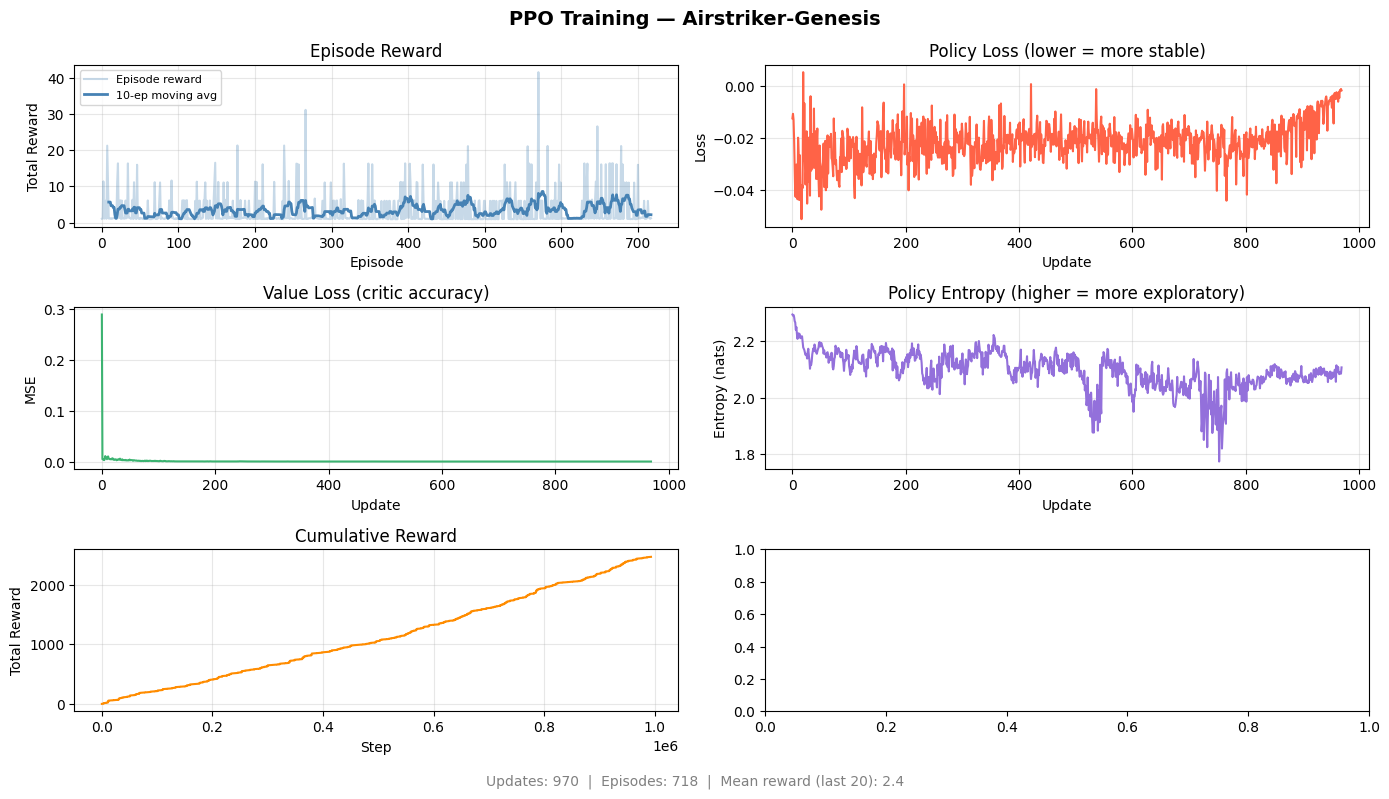

Update  970 | Steps:  993,280 | FPS:    140 | Mean reward (last 20):      2.4 | Policy loss: -0.0018 | Entropy: 2.107
------------------------------------------------------------
Training complete! Total time: 119.0 minutes
Model saved to ppo_airstriker.pt


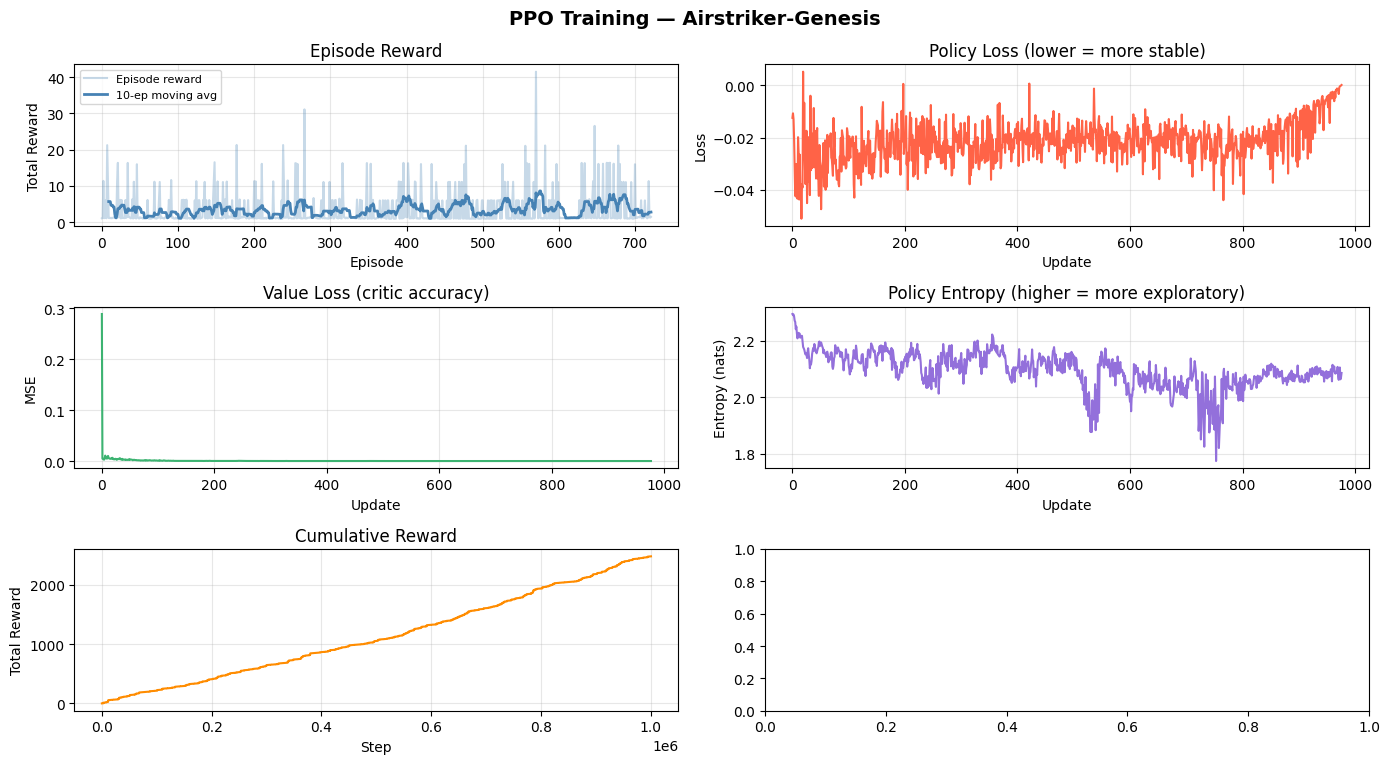

In [108]:


agent, rewards = train()

---
##  Evaluation


In [113]:
def evaluate(agent, n_episodes=5, render=True):
    
    env = make_env()
    frame_stack = FrameStack(k=N_STACK, frame_size=FRAME_SIZE)
    ep_rewards = []

    agent.network.eval()
    with torch.no_grad():
        for ep in range(n_episodes):
            obs, _ = env_reset(env, frame_stack)
            ep_reward = 0.0
            done = False

            while not done:
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                logits, _ = agent.network(obs_t)
                # Greedy action — no sampling during eval
                action = logits.argmax(dim=-1).item()

                obs, reward, done, _ = env_step(env, frame_stack, action)
                ep_reward += reward

            ep_rewards.append(ep_reward)
            print(f"  Episode {ep + 1}: reward = {ep_reward:.1f}")

    env.close()
    print(f"\nMean reward: {np.mean(ep_rewards):.1f} ± {np.std(ep_rewards):.1f}")
    return ep_rewards


eval_rewards = evaluate(agent, n_episodes=5)

  Episode 1: reward = 6900.3
  Episode 2: reward = 6900.3
  Episode 3: reward = 6900.3
  Episode 4: reward = 6900.3
  Episode 5: reward = 6900.3

Mean reward: 6900.3 ± 0.0


In [110]:
# check a few steps manually
env = make_env()
frame_stack = FrameStack(k=N_STACK, frame_size=FRAME_SIZE)
obs, _ = env_reset(env, frame_stack)

rewards = []
for i in range(100):
    action = np.random.randint(N_ACTIONS)
    obs, reward, done, info = env_step(env, frame_stack, action)
    rewards.append(reward)
    if done:
        obs, _ = env_reset(env, frame_stack)

env.close()
print(f"Min reward:  {min(rewards):.4f}")
print(f"Max reward:  {max(rewards):.4f}")
print(f"Mean reward: {np.mean(rewards):.4f}")
print(f"Non-zero rewards: {sum(1 for r in rewards if r != 0)}")

Min reward:  0.0010
Max reward:  0.0010
Mean reward: 0.0010
Non-zero rewards: 100


In [111]:
env = make_env()
frame_stack = FrameStack(k=N_STACK, frame_size=FRAME_SIZE)
obs, _ = env_reset(env, frame_stack)

for i in range(10):
    obs, reward, done, info = env_step(env, frame_stack, 5)  # action 5 = FIRE
    print(f"Step {i}: reward={reward:.4f}, info={info}")

env.close()

Step 0: reward=0.0010, info={'gameover': 9, 'lives': 3, 'score': 0}
Step 1: reward=0.0010, info={'gameover': 9, 'lives': 3, 'score': 0}
Step 2: reward=0.0010, info={'gameover': 9, 'lives': 3, 'score': 0}
Step 3: reward=0.0010, info={'gameover': 9, 'lives': 3, 'score': 0}
Step 4: reward=0.0010, info={'gameover': 9, 'lives': 3, 'score': 0}
Step 5: reward=0.0010, info={'gameover': 9, 'lives': 3, 'score': 0}
Step 6: reward=0.0010, info={'gameover': 9, 'lives': 3, 'score': 0}
Step 7: reward=0.0010, info={'gameover': 9, 'lives': 3, 'score': 0}
Step 8: reward=0.0010, info={'gameover': 9, 'lives': 3, 'score': 0}
Step 9: reward=0.0010, info={'gameover': 9, 'lives': 3, 'score': 0}


In [112]:
try:
    env.close()
except:
    pass